<a href="https://colab.research.google.com/github/Ivan35-arch/handwritting_training/blob/main/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Directory structure created under './mnist_dataset/'
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Data split summary:
Train samples:      54000
Validation samples: 6000
Test samples:       10000
Saving train images to disk...
Saving val images to disk...
Saving test images to disk...
All images successfully written to local disk structure!

Generating sample grid visualization...


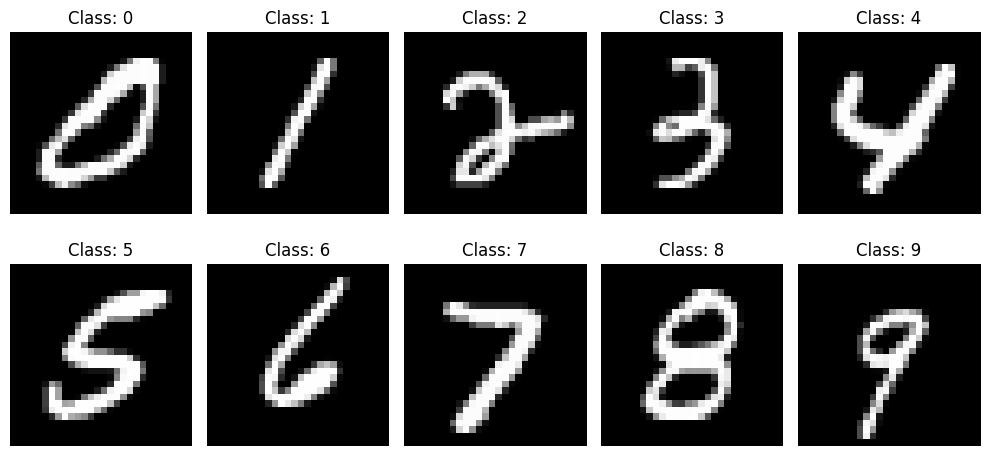

In [ ]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split

# ==========================================
# 1. SETUP DIRECTORIES
# ==========================================
# Define the root dataset folder
DATASET_DIR = "mnist_dataset"

# Clean up any existing directory to start fresh
if os.path.exists(DATASET_DIR):
    shutil.rmtree(DATASET_DIR)

# Create subfolders for train, val, and test, each containing subfolders for digits 0-9
splits = ['train', 'val', 'test']
for split in splits:
    for digit in range(10):
        os.makedirs(os.path.join(DATASET_DIR, split, str(digit)), exist_ok=True)

print(f"Directory structure created under './{DATASET_DIR}/'")

# ==========================================
# 2. LOAD AND SPLIT MNIST
# ==========================================
# Load the built-in MNIST dataset
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Split the original 60,000 training set into Train (90%) and Validation (10%)
# Stratify ensures we keep an equal distribution of digits 0-9 in both splits
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.10,
    random_state=42,
    stratify=y_train_full
)

print(f"\nData split summary:")
print(f"Train samples:      {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples:       {X_test.shape[0]}")

# ==========================================
# 3. WRITE ARRAYS TO DISK AS IMAGES
# ==========================================
def save_numpy_as_images(images, labels, split_name):
    """Helper function to save numpy arrays into class-specific folders as PNGs"""
    print(f"Saving {split_name} images to disk...")
    for idx, (img_array, label) in enumerate(zip(images, labels)):
        # Convert numpy array to PIL Image
        img = Image.fromarray(img_array.astype(np.uint8))

        # Define filename (e.g., mnist_dataset/train/5/img_12.png)
        file_path = os.path.join(DATASET_DIR, split_name, str(label), f"img_{idx}.png")
        img.save(file_path)

# Run the saving loop for all splits
save_numpy_as_images(X_train, y_train, 'train')
save_numpy_as_images(X_val, y_val, 'val')
save_numpy_as_images(X_test, y_test, 'test')
print("All images successfully written to local disk structure!")

# ==========================================
# 4. VISUALIZE GRID OF SAMPLES (FOR YOUR REPORT)
# ==========================================
print("\nGenerating sample grid visualization...")
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()

# Display the first instance found for each digit (0-9) from the training set
for digit in range(10):
    # Find the index of the first occurrence of this digit
    first_idx = np.where(y_train == digit)[0][0]

    # Plot it
    axes[digit].imshow(X_train[first_idx], cmap='gray')
    axes[digit].set_title(f"Class: {digit}")
    axes[digit].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Configuration constants
BATCH_SIZE = 64
IMG_SIZE = (28, 28)  # Already 28x28, but explicitly defined for data loaders

# ==========================================
# 1. CREATE DATA INPUT PIPELINES
# ==========================================
print("Creating TensorFlow Datasets from local directories...")

# Training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    'mnist_dataset/train',
    labels='inferred',
    label_mode='categorical',     # Outputs one-hot encoded labels (e.g., [1,0,0,...])
    color_mode='grayscale',       # Forces shape to (28, 28, 1) to add channel dimension
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True
)

# Validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    'mnist_dataset/val',
    labels='inferred',
    label_mode='categorical',
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False                 # No need to shuffle validation data
)

# Test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    'mnist_dataset/test',
    labels='inferred',
    label_mode='categorical',
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False                 # No need to shuffle test data
)


# ==========================================
# 2. DEFINE PREPROCESSING & AUGMENTATION LAYERS
# ==========================================
# This sequential layer container will be embedded directly at the start of our model
data_augmentation_and_preprocessing = tf.keras.Sequential([
    # A. Normalization (Rescale pixel values from [0, 255] to [0.0, 1.0])
    tf.keras.layers.Rescaling(1./255),

    # B. Mild Data Augmentation
    tf.keras.layers.RandomRotation(
        factor=0.03,              # ~10 degrees maximum rotation (-10 to +10)
        fill_mode='constant',     # Fills empty space created by rotation with a solid color
        fill_value=0.0            # Fills with black (0), matching MNIST background
    ),
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,       # Mild vertical shifts (~5% max)
        width_factor=0.05,        # Mild horizontal shifts (~5% max)
        fill_mode='constant',
        fill_value=0.0
    ),
    tf.keras.layers.RandomZoom(
        height_factor=(-0.05, 0.05), # Mild zoom in/out (5% max)
        fill_mode='constant',
        fill_value=0.0
    )
], name="preprocessing_and_augmentation")


# ==========================================
# 3. PERFORMANCE OPTIMIZATION
# ==========================================
# AUTOTUNE dynamically adjusts buffer sizes based on your Colab hardware constraints
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("\nData pipelines optimized and ready.")

Creating TensorFlow Datasets from local directories...
Found 54000 files belonging to 10 classes.
Found 6000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.

Data pipelines optimized and ready.


In [ ]:
from tensorflow.keras import layers, models

def build_mnist_cnn(preprocessing_layer):
    """
    Builds a robust Convolutional Neural Network (CNN) for MNIST digit classification.
    Integrates the preprocessing and augmentation pipeline directly into the architecture.
    """
    model = models.Sequential([
        # 1. INPUT LAYER
        # Explicitly declare the expected input shape: 28x28 grayscale pixels
        layers.Input(shape=(28, 28, 1), name="input_layer"),

        # 2. INTEGRATED PREPROCESSING & AUGMENTATION
        # This applies normalization and mild shifts/rotations during training
        preprocessing_layer,

        # 3. FIRST CONVOLUTIONAL BLOCK
        # Extracts 32 low-level spatial features (edges, corners)
        layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', name="conv_1"),
        layers.MaxPooling2D(pool_size=(2, 2), name="pool_1"),

        # 4. SECOND CONVOLUTIONAL BLOCK
        # Combines features into 64 higher-level patterns (curves, loops)
        layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu', name="conv_2"),
        layers.MaxPooling2D(pool_size=(2, 2), name="pool_2"),

        # 5. FLATTEN LAYER
        # Converts 2D feature maps into a 1D vector for the fully-connected layers
        layers.Flatten(name="flatten"),

        # 6. FULLY-CONNECTED (DENSE) LAYER
        # Performs reasoning based on the extracted spatial features
        layers.Dense(units=128, activation='relu', name="dense_hidden"),

        # 7. REGULARIZATION (DROPOUT)
        # Randomly turns off 40% of neurons during each training step to prevent overfitting
        layers.Dropout(0.4, name="dropout"),

        # 8. OUTPUT LAYER
        # 10 units representing classes 0-9. Softmax converts outputs to clean probabilities.
        layers.Dense(units=10, activation='softmax', name="output_layer")
    ], name="MNIST_Handwritten_Digit_Classifier")

    return model

# Initialize the model using the preprocessing container from Step 2
model = build_mnist_cnn(data_augmentation_and_preprocessing)

# ==========================================
# COMPILATION
# ==========================================
# We use categorical crossentropy because our labels are one-hot encoded (categorical)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display the network structure
model.summary()

Model: "MNIST_Handwritten_Digit_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ preprocessing_and_augmentation  │ (None, 28, 28, 1)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Starting training loop...
Epoch 1/20
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8013 - loss: 0.6179
Epoch 1: val_loss improved from None to 0.06152, saving model to best_mnist_model.keras

Epoch 1: finished saving model to best_mnist_model.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 65s 73ms/step - accuracy: 0.9028 - loss: 0.3103 - val_accuracy: 0.9813 - val_loss: 0.0615
Epoch 2/20
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9607 - loss: 0.1312
Epoch 2: val_loss improved from 0.06152 to 0.04641, saving model to best_mnist_model.keras

Epoch 2: finished saving model to best_mnist_model.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 73ms/step - accuracy: 0.9650 - loss: 0.1169 - val_accuracy: 0.9877 - val_loss: 0.0464
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9713 - loss: 0.0925
Epoch 3: val_loss improved from 0.04641 to 0.03943, saving model to best_mnist_model.keras

Epoch 3: finished saving model to best_mnist_model.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 82

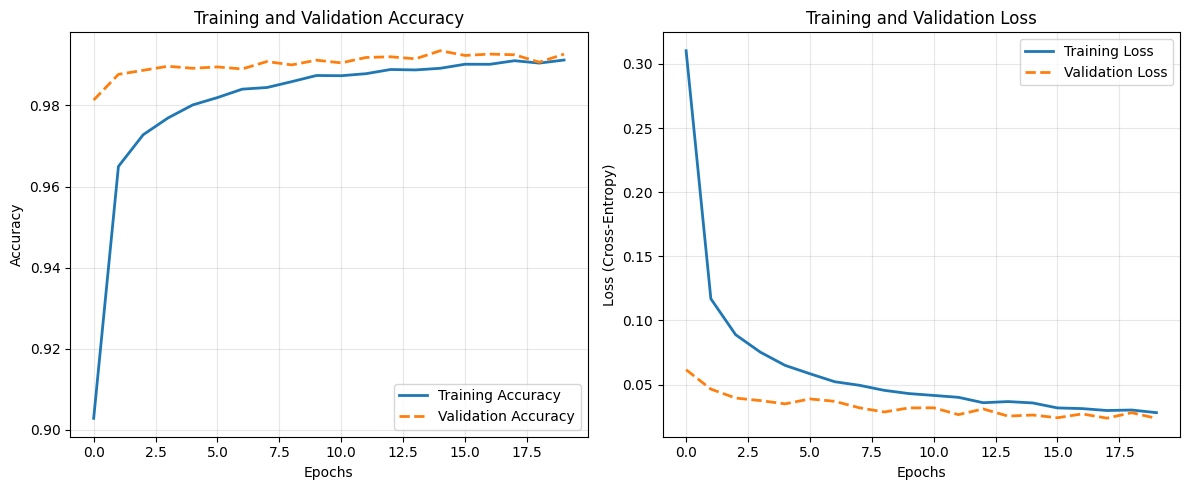

In [ ]:
from tensorflow.keras import callbacks

# ==========================================
# 1. CONFIGURE CALLBACKS
# ==========================================
checkpoint_cb = callbacks.ModelCheckpoint(
    filepath='best_mnist_model.keras',
    monitor='val_loss',
    save_best_only=True,       # Only overwrite if validation loss improves
    verbose=1
)

early_stopping_cb = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,                # Stop if val_loss doesn't improve for 3 consecutive epochs
    restore_best_weights=True, # Revert model to its peak performance state
    verbose=1
)

# ==========================================
# 2. TRAIN THE MODEL
# ==========================================
EPOCHS = 20  # Early stopping will likely cut this short around epoch 5-10

print("Starting training loop...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb, early_stopping_cb]
)

# ==========================================
# 3. PLOT TRAINING HISTORY (FOR YOUR REPORT)
# ==========================================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy Curves
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Plot Loss Curves
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (Cross-Entropy)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("\nEvaluating model performance on the hold-out Test Set...")
test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

print("=========================================")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print("=========================================")


Evaluating model performance on the hold-out Test Set...
Test Loss:     0.0207
Test Accuracy: 99.37%


In [ ]:
from tensorflow.keras import layers, models

def build_fully_optimized_cnn(preprocessing_layer):
    """
    An optimized CNN featuring 5 core optimization techniques:
    1. Integrated Data Augmentation
    2. Batch Normalization (stabilizes and speeds up training)
    3. Spatial Convolutional layers
    4. Dropout Regularization (prevents overfitting)
    5. Dynamic Callback Optimization (configured next)
    """
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1), name="input_layer"),

        # [Tech 1] Preprocessing & Augmentation Layer
        preprocessing_layer,

        # First Conv Block
        layers.Conv2D(32, kernel_size=(3, 3), padding='same', name="conv_1"),
        layers.BatchNormalization(name="batchnorm_1"), # [Tech 2a] Batch Normalization
        layers.Activation('relu', name="relu_1"),
        layers.MaxPooling2D(pool_size=(2, 2), name="pool_1"),

        # Second Conv Block
        layers.Conv2D(64, kernel_size=(3, 3), padding='same', name="conv_2"),
        layers.BatchNormalization(name="batchnorm_2"), # [Tech 2b] Batch Normalization
        layers.Activation('relu', name="relu_2"),
        layers.MaxPooling2D(pool_size=(2, 2), name="pool_2"),

        layers.Flatten(name="flatten"),

        # Fully Connected Block
        layers.Dense(128, name="dense_hidden"),
        layers.BatchNormalization(name="batchnorm_dense"), # [Tech 2c] Batch Normalization
        layers.Activation('relu', name="relu_dense"),

        # [Tech 3] Dropout Regularization
        layers.Dropout(0.4, name="dropout"),

        layers.Dense(10, activation='softmax', name="output_layer")
    ], name="Fully_Optimized_MNIST_Classifier")

    return model

# Re-instantiate the model with the new architecture
optimized_model = build_fully_optimized_cnn(data_augmentation_and_preprocessing)

# Compile with Adam optimizer
optimized_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

optimized_model.summary()

Model: "Fully_Optimized_MNIST_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ preprocessing_and_augmentation  │ (None, 28, 28, 1)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_1                     │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_2                     │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_dense                 │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,538 (1.61 MB)

 Trainable params: 422,090 (1.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
from tensorflow.keras import callbacks

# ==========================================
# CONFIGURE ALL OPTIMIZATION CALLBACKS
# ==========================================

# [Tech 4] Model Checkpoint: Saves peak model weights
checkpoint_cb = callbacks.ModelCheckpoint(
    filepath='best_optimized_mnist_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# [Tech 5] Early Stopping: Prevents unnecessary overtraining
early_stopping_cb = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,                 # Stops if validation loss stagnates for 4 epochs
    restore_best_weights=True,
    verbose=1
)

# [Tech 6] Reduce Learning Rate on Plateau: Automatically drops learning rate
# when validation loss slows down, allowing the model to make finer, sharper steps.
reduce_lr_cb = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,                 # Multiplies current learning rate by 0.2 (e.g., 0.001 -> 0.0002)
    patience=2,                 # Drops rate if val_loss doesn't improve for 2 straight epochs
    min_lr=1e-6,                # Absolute floor for the learning rate
    verbose=1
)

# ==========================================
# RUN THE FINAL OPTIMIZED TRAINING
# ==========================================
EPOCHS = 20

print("Starting fully optimized training pipeline...")
history = optimized_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb]
)

Starting fully optimized training pipeline...
Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.8997 - loss: 0.3459
Epoch 1: val_loss improved from None to 0.07368, saving model to best_optimized_mnist_model.keras

Epoch 1: finished saving model to best_optimized_mnist_model.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 116s 132ms/step - accuracy: 0.9476 - loss: 0.1831 - val_accuracy: 0.9778 - val_loss: 0.0737 - learning_rate: 0.0010
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.9727 - loss: 0.0905
Epoch 2: val_loss did not improve from 0.07368
844/844 ━━━━━━━━━━━━━━━━━━━━ 112s 132ms/step - accuracy: 0.9749 - loss: 0.0826 - val_accuracy: 0.9762 - val_loss: 0.0753 - learning_rate: 0.0010
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9781 - loss: 0.0712
Epoch 3: val_loss improved from 0.07368 to 0.04958, saving model to best_optimized_mnist_model.keras

Epoch 3: finished saving model to best_optimized_mnist_model.keras
844/844 ━━━━━━━━━━

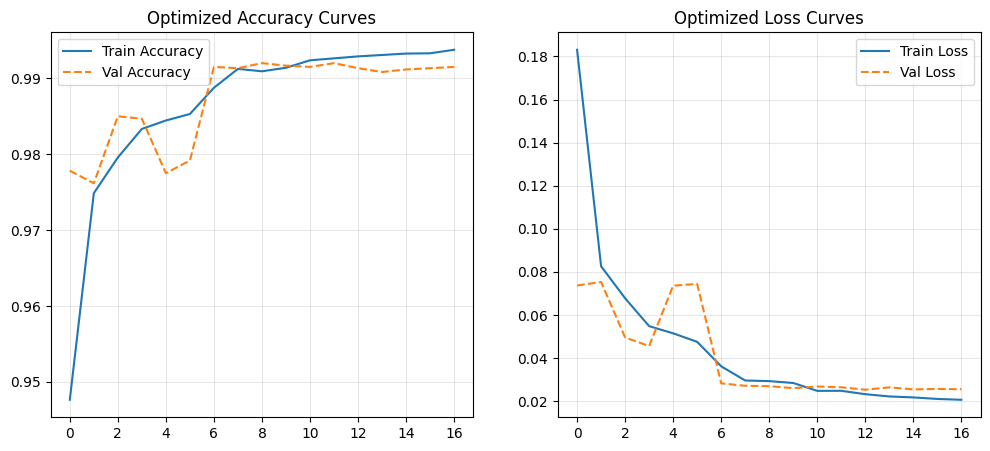


Evaluating against hold-out test folders...
Final Test Accuracy: 99.42%
Final Test Loss:     0.0201


In [ ]:
import matplotlib.pyplot as plt

# Plot execution metrics
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Val Accuracy', linestyle='--')
plt.title('Optimized Accuracy Curves')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss', linestyle='--')
plt.title('Optimized Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Final unbiased test evaluation
print("\nEvaluating against hold-out test folders...")
test_loss, test_accuracy = optimized_model.evaluate(test_ds, verbose=0)
print("=========================================")
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Loss:     {test_loss:.4f}")
print("=========================================")

Running inference on 5 unseen test images...


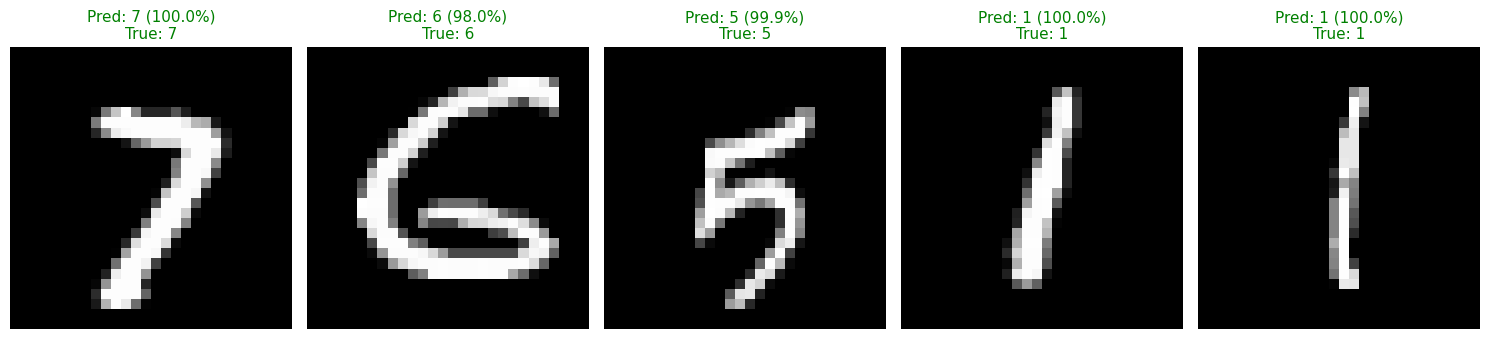

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ==========================================
# 1. SELECT 5 RANDOM UNSEEN IMAGES
# ==========================================
test_root = "mnist_dataset/test"
all_test_images = []

# Gather paths of all images in the test folders
for digit_class in os.listdir(test_root):
    class_dir = os.path.join(test_root, digit_class)
    if os.path.isdir(class_dir):
        for img_name in os.listdir(class_dir):
            all_test_images.append((os.path.join(class_dir, img_name), digit_class))

# Sample exactly 5 random images
random.seed(42)  # For reproducible sampling
sampled_images = random.sample(all_test_images, 5)

# ==========================================
# 2. RUN INFERENCE & VISUALIZE
# ==========================================
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

print("Running inference on 5 unseen test images...")
for idx, (img_path, true_label) in enumerate(sampled_images):
    # Load and preprocess image to match model input requirements
    img = tf.keras.utils.load_img(img_path, color_mode='grayscale', target_size=(28, 28))
    img_array = tf.keras.utils.img_to_array(img)
    img_tensor = tf.expand_dims(img_array, 0) # Add batch dimension -> (1, 28, 28, 1)

    # Predict (The embedded preprocessing layer automatically scales pixel values)
    predictions = optimized_model.predict(img_tensor, verbose=0)
    predicted_class = np.argmax(predictions)
    confidence = np.max(predictions) * 100

    # Plotting setup
    axes[idx].imshow(img_array.squeeze(), cmap='gray')
    color = 'green' if str(predicted_class) == true_label else 'red'

    axes[idx].set_title(
        f"Pred: {predicted_class} ({confidence:.1f}%)\nTrue: {true_label}",
        color=color,
        fontsize=11
    )
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf

print("Initiating TensorFlow Lite conversion pipeline...")

# 1. Initialize the converter using the trained Keras model
converter = tf.lite.TFLiteConverter.from_keras_model(optimized_model)

# 2. Convert the architecture and weights to the TFLite binary format
tflite_model = converter.convert()

# 3. Save the serialized model asset to disk
tflite_model_path = "mnist_model.tflite"
with open(tflite_model_path, "wb") as f:
    f.write(tflite_model)

print("--------------------------------------------------")
print(f"Deployment Asset Successfully Compiled: {tflite_model_path}")
print(f"Keras Model Size:  {os.path.getsize('best_optimized_mnist_model.keras') / 1024:.2f} KB")
print(f"TFLite Model Size: {os.path.getsize(tflite_model_path) / 1024:.2f} KB")
print("--------------------------------------------------")

Initiating TensorFlow Lite conversion pipeline...
Saved artifact at '/tmp/tmplxt4ai9_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  132480197907216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132480197908560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132480197905104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132480197909520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132480197909328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132480197908752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132480197909136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132480197908176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132480197906064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132480197910672: TensorSpec(shape=()